# Further Fine-Tuning — READ `checkpoint-8368` on the Bullinger (ENHG) train set

We resume from the READ/Bozen fine-tuned TrOCR checkpoint (`checkpoint-8368`) and continue
training on the [Bullinger HTR dataset](https://github.com/pstroe/bullinger-htr) — 16th-century
correspondence of Heinrich Bullinger. Bullinger is multilingual (Latin `la/` + Early New High
German `de/`); the model is German-adapted, so we keep only the **`de/` (ENHG)** subset.

**Scope:** we train only on the **`train/0-2000-out`** archive set (by document-ID range). The
lines are already cropped (`.png` + `.txt` pairs — no PAGE-XML step), so they flow straight
through the same Dataset / Trainer pipeline used for the Bentham and READ fine-tunes.

- **Train** = `train/0-2000-out` — a **split multi-volume** zip (`…-out.z01..z0N` + `…-out.zip`,
  ~14 GB of parts). All volumes are downloaded, unified with `zip -F`, then extracted.
- **Validation** = `test/0-2000-out.zip` — a single ~1.85 GB archive (694 German lines); the
  dataset's own 0-2000 test split, used here to track CER/WER each epoch.

> We start a **fresh optimizer** (we do not load the checkpoint's optimizer state) — the right
> choice when adapting to a new dataset.

**Run on a Colab GPU runtime** (Runtime → Change runtime type → GPU; this was developed on an L4).
The unified train zip + extracted crops need a fair bit of local disk — a high-RAM/L4 runtime is
recommended.

In [1]:
# Colab has torch + transformers; evaluate/jiwer are needed for CER/WER.
!pip -q install evaluate jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 122.4 MB/s eta 0:00:00


In [2]:
import os
import zipfile
import subprocess
import urllib.request
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import evaluate

from glob import glob
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from transformers import (
    TrOCRProcessor,
    VisionEncoderDecoderModel,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    default_data_collator,
)

plt.rcParams["figure.figsize"] = (12, 4)

# Mount Drive
The checkpoint to resume from lives on Drive, and new checkpoints are saved back to Drive.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
def seed_everything(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

# Run on a GPU runtime (Colab: Runtime -> Change runtime type -> GPU, e.g. L4/T4/A100).
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE_TYPE = device.type  # "cuda" or "cpu"
print(f"Using device: {device}  (type: {DEVICE_TYPE})")
if DEVICE_TYPE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: no GPU detected — select a GPU runtime for reasonable training speed.")

Using device: cuda  (type: cuda)
GPU: NVIDIA L4


# Config

In [5]:
# --- Resume from the READ/Bozen fine-tune checkpoint (lives on Drive) ---
CHECKPOINT_DIR = "/content/drive/MyDrive/READ/models/read_trocr_checkpoint/checkpoint-8368"
BASE_MODEL     = "microsoft/trocr-base-handwritten"  # processor source (unchanged by fine-tuning)

# Where new Bullinger checkpoints are saved (Drive, so they survive the session).
BULLINGER_OUTPUT_DIR = "/content/drive/MyDrive/Bullinger/models/bullinger_trocr_checkpoint"

# --- generation / batching ---
MAX_TARGET_LENGTH = 128
BATCH_SIZE        = 8
NUM_BEAMS         = 4

# --- training hyper-parameters ---
EPOCHS        = 8
LEARNING_RATE = 2e-5   # low LR: we resume from an already-trained checkpoint

print("Resume from:", CHECKPOINT_DIR)
print("Output to  :", BULLINGER_OUTPUT_DIR)

Resume from: /content/drive/MyDrive/READ/models/read_trocr_checkpoint/checkpoint-8368
Output to  : /content/drive/MyDrive/Bullinger/models/bullinger_trocr_checkpoint


In [6]:
# Bullinger HTR data — Git-LFS zip archives served via the GitHub media endpoint.
# train/0-2000-out is a SPLIT multi-volume zip (…-out.z01..z0N + …-out.zip, ~14 GB of parts);
# test/0-2000-out.zip is a single ~1.85 GB archive. We train on the train set's de/ lines and
# validate on the test set's de/ lines (the dataset's own 0-2000 split).
BULLINGER_ROOT = "https://media.githubusercontent.com/media/pstroe/bullinger-htr/main"

TRAIN_ARCHIVE = "0-2000-out"        # train split: multi-volume -> download all parts + unify
VAL_ARCHIVE   = "0-2000-out.zip"    # test split: single zip, used here as validation
LANG          = "de"                # keep only the German (ENHG) subset

# Local ephemeral Colab disk (fast; Drive is slow with many tiny files).
DL_DIR      = "/content/bullinger_dl"
EXTRACT_DIR = "/content/bullinger_data"

print("train archive:", TRAIN_ARCHIVE, "| val archive:", VAL_ARCHIVE, "| lang:", LANG)

train archive: 0-2000-out | val archive: 0-2000-out.zip | lang: de


# Download & Extract
Only the German (`de/`) members are extracted. Downloads use `wget -c`, so a re-run resumes
rather than re-downloading. The split train set is unified with `zip -F` (per the dataset README)
before extraction.

In [7]:
def _remote_exists(url):
    """True if the URL responds 200 to a HEAD request (used to probe split parts)."""
    try:
        with urllib.request.urlopen(urllib.request.Request(url, method="HEAD")) as r:
            return r.status == 200
    except Exception:
        return False

def fetch_split_archive(split, base):
    """Download one split (multi-volume) archive set and unify it into one openable .zip."""
    dl = os.path.join(DL_DIR, split)
    os.makedirs(dl, exist_ok=True)
    root = f"{BULLINGER_ROOT}/{split}/{base}"

    # Discover split volume parts (.z01, .z02, ...) until one is missing.
    parts, i = [], 1
    while _remote_exists(f"{root}.z{i:02d}"):
        parts.append(f"{base}.z{i:02d}")
        i += 1
    parts.append(f"{base}.zip")            # the final volume is always present

    for p in parts:
        dest = os.path.join(dl, p)
        print(f"  downloading {p} ...")
        !wget -c -q --show-progress -O "{dest}" "{BULLINGER_ROOT}/{split}/{p}"

    final_zip = os.path.join(dl, f"{base}.zip")
    if len(parts) == 1:
        return final_zip                   # single-file archive

    single = os.path.join(dl, f"single-{base}.zip")
    if not os.path.exists(single):
        print(f"  unifying {len(parts)} split volumes -> single-{base}.zip")
        subprocess.run(["zip", "-F", final_zip, "--out", single],
                       check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    return single

def fetch_single_archive(split, archive):
    """Download one single-file archive (e.g. a test/ zip)."""
    dl = os.path.join(DL_DIR, split)
    os.makedirs(dl, exist_ok=True)
    dest = os.path.join(dl, archive)
    print(f"  downloading {archive} ...")
    !wget -c -q --show-progress -O "{dest}" "{BULLINGER_ROOT}/{split}/{archive}"
    return dest

def extract_and_index(zpath, out_split):
    """Extract only the de/ members of one zip and return a (file_name, text) DataFrame."""
    ext = os.path.join(EXTRACT_DIR, out_split)
    os.makedirs(ext, exist_ok=True)
    with zipfile.ZipFile(zpath) as zf:
        members = [m for m in zf.namelist() if f"/{LANG}/" in m]
        zf.extractall(ext, members=members)
    print(f"  extracted {len(members)} {LANG}/ members from {os.path.basename(zpath)}")

    rows = []
    for p in sorted(glob(os.path.join(ext, "**", LANG, "*.png"), recursive=True)):
        txt = p[:-4] + ".txt"
        if os.path.exists(txt):
            with open(txt, encoding="utf-8") as f:
                text = f.read().strip()
            if text:
                rows.append({"file_name": p, "text": text})
    return pd.DataFrame(rows).reset_index(drop=True)

In [8]:
os.makedirs(DL_DIR, exist_ok=True)
os.makedirs(EXTRACT_DIR, exist_ok=True)

print(f"[train] {TRAIN_ARCHIVE}")
train_zip = fetch_split_archive("train", TRAIN_ARCHIVE)
train_df  = extract_and_index(train_zip, "train")

print(f"[val] {VAL_ARCHIVE}")
val_zip = fetch_single_archive("test", VAL_ARCHIVE)
val_df  = extract_and_index(val_zip, "val")

print(f"\nTrain ({LANG}): {len(train_df)} lines | Val ({LANG}): {len(val_df)} lines")
train_df.head()

[train] 0-2000-out
  downloading 0-2000-out.z01 ...
/content/bullinger_ 100%[===================>]   2.00G  31.9MB/s    in 61s     
  downloading 0-2000-out.z02 ...
/content/bullinger_ 100%[===================>]   2.00G  16.7MB/s    in 54s     
  downloading 0-2000-out.z03 ...
/content/bullinger_ 100%[===================>]   2.00G   183MB/s    in 5.5s    
  downloading 0-2000-out.z04 ...
/content/bullinger_ 100%[===================>]   2.00G   184MB/s    in 6.2s    
  downloading 0-2000-out.z05 ...
/content/bullinger_ 100%[===================>]   2.00G   198MB/s    in 6.0s    
  downloading 0-2000-out.z06 ...
/content/bullinger_ 100%[===================>]   2.00G   358MB/s    in 4.6s    
  downloading 0-2000-out.zip ...
/content/bullinger_ 100%[===================>]   1.40G  17.3MB/s    in 86s     
  unifying 7 split volumes -> single-0-2000-out.zip
  extracted 11579 de/ members from single-0-2000-out.zip
[val] 0-2000-out.zip
  downloading 0-2000-out.zip ...
/content/bullinger_ 100%[==

,file_name,text
0,/content/bullinger_data/train/0-2000-out/de/10...,teneo.
1,/content/bullinger_data/train/0-2000-out/de/10...,mynem gunstigen hern.
2,/content/bullinger_data/train/0-2000-out/de/10...,Zurich.
3,/content/bullinger_data/train/0-2000-out/de/10...,"es aber publiciert, werden alle engelendische,..."
4,/content/bullinger_data/train/0-2000-out/de/10...,oberländisch unnd italianisch kaufleut hinwegk...


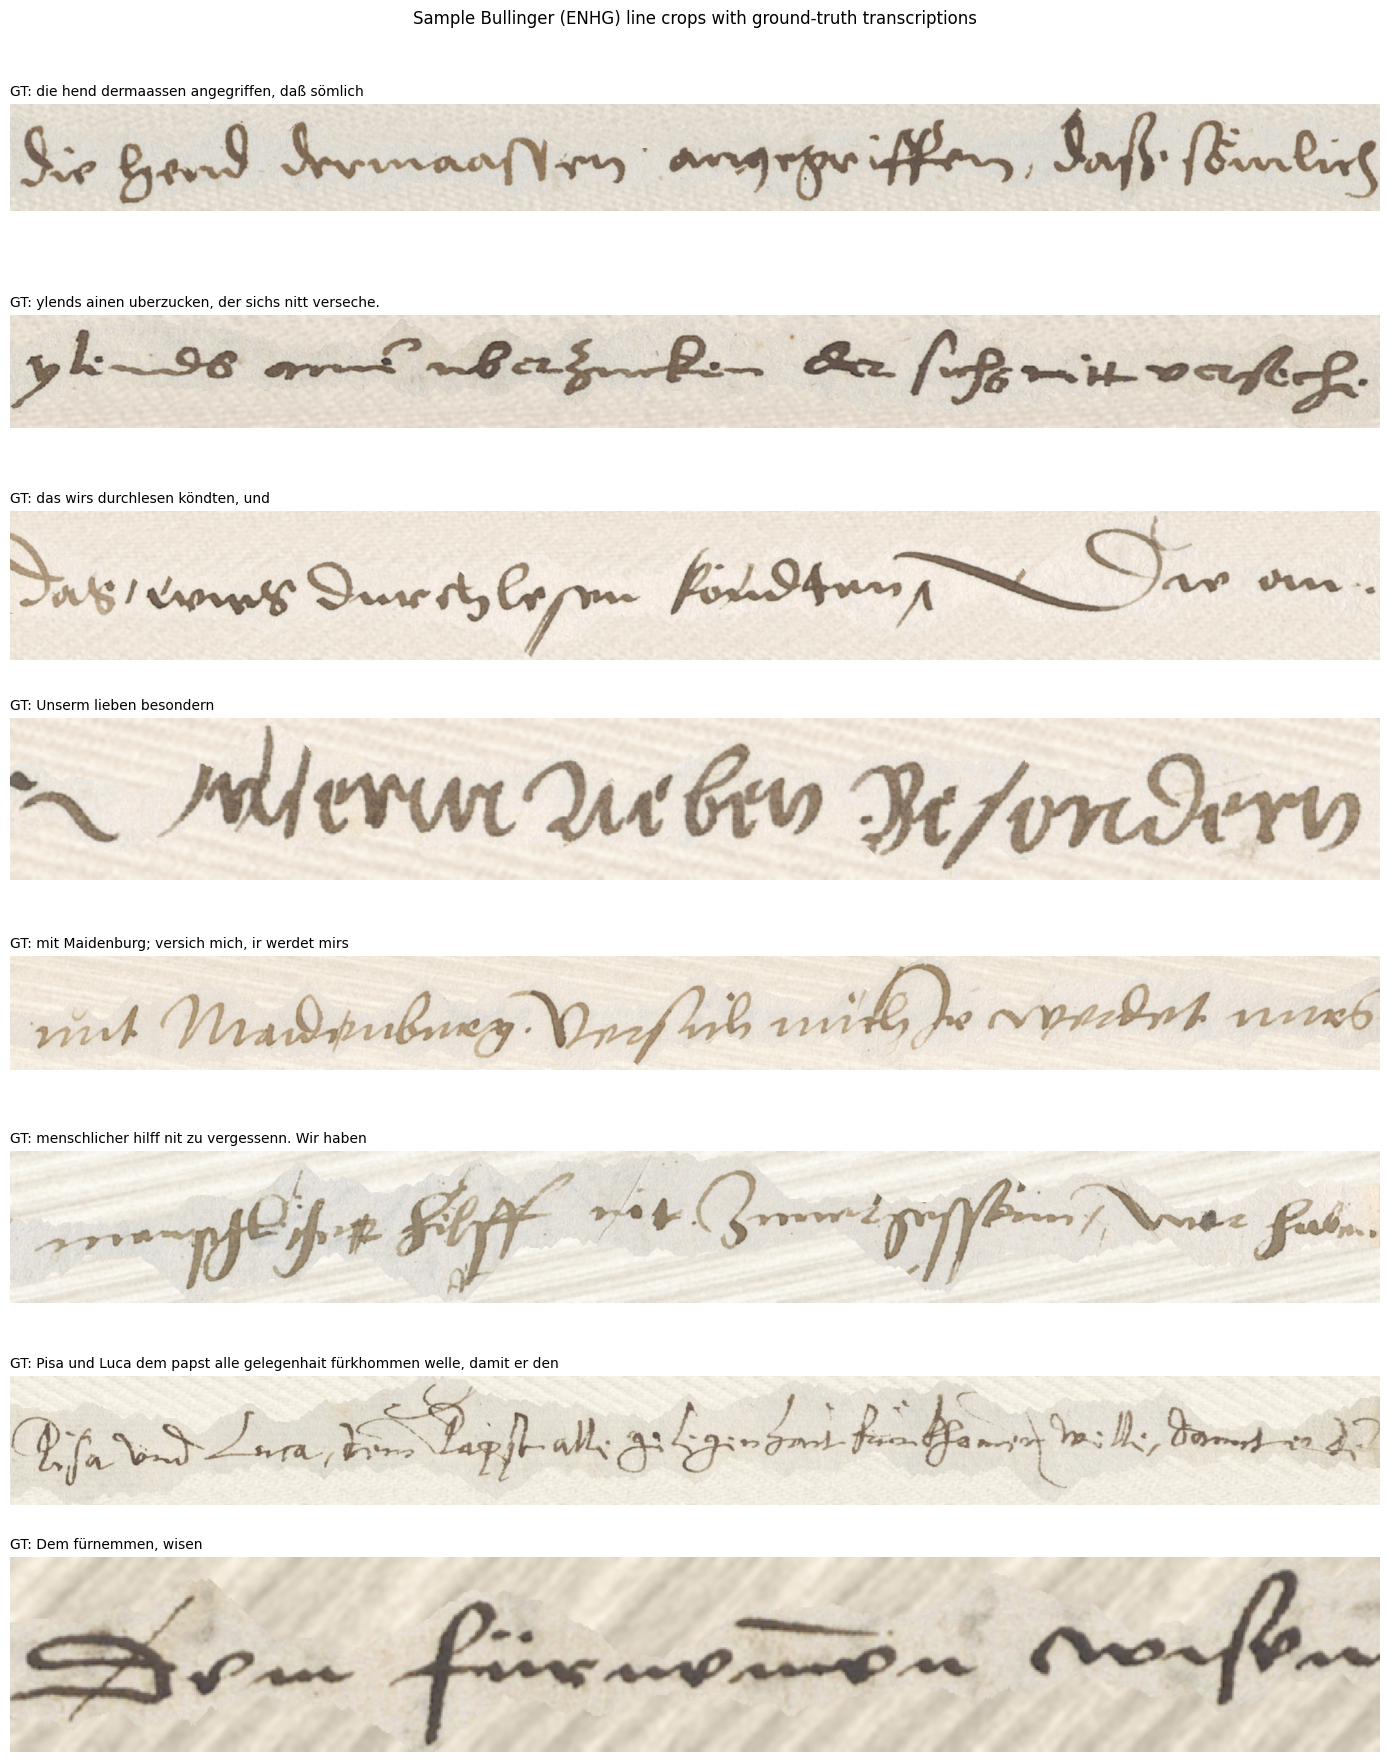

Transcription char length — min 2, median 49, mean 48.1, max 137
Lines longer than MAX_TARGET_LENGTH=128: 2 of 5789


In [9]:
# Visualise sample line crops with their ground-truth transcriptions
N_SHOW = 8
sample = train_df.sample(min(N_SHOW, len(train_df)), random_state=42).reset_index(drop=True)

fig, axes = plt.subplots(len(sample), 1, figsize=(14, 2.2 * len(sample)))
for ax, row in zip(axes, sample.itertuples()):
    ax.imshow(Image.open(row.file_name), cmap="gray")
    ax.set_title(f"GT: {row.text}", fontsize=10, loc="left")
    ax.axis("off")
plt.suptitle("Sample Bullinger (ENHG) line crops with ground-truth transcriptions", y=1.0)
plt.tight_layout()
plt.show()

# Quick text-length stats — helps confirm MAX_TARGET_LENGTH is large enough
char_lens = train_df["text"].str.len()
print(f"Transcription char length — min {char_lens.min()}, "
      f"median {int(char_lens.median())}, mean {char_lens.mean():.1f}, max {char_lens.max()}")
print(f"Lines longer than MAX_TARGET_LENGTH={MAX_TARGET_LENGTH}: "
      f"{(char_lens > MAX_TARGET_LENGTH).sum()} of {len(train_df)}")

# Dataset, Model & Metrics

In [10]:
# Same Dataset + transforms used for Bentham and READ, so the Bullinger lines flow through
# the identical preprocessing pipeline. The dataset objects are built after the processor
# loads (next cell).
class LineOCRDataset(Dataset):
    def __init__(self, df, processor, transforms=None, max_target_length=128):
        self.df = df.reset_index(drop=True)
        self.processor = processor
        self.transforms = transforms
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image = Image.open(self.df["file_name"][idx]).convert("RGB")
        if self.transforms:
            image = self.transforms(image)

        pixel_values = self.processor(image, return_tensors="pt").pixel_values

        labels = self.processor.tokenizer(
            self.df["text"][idx],
            padding="max_length",
            max_length=self.max_target_length,
            truncation=True,
        ).input_ids
        # Replace padding token id with -100 so it is ignored in the loss
        labels = [l if l != self.processor.tokenizer.pad_token_id else -100 for l in labels]

        return {
            "pixel_values": pixel_values.squeeze(),
            "labels": torch.tensor(labels),
        }

train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomAffine(degrees=2, translate=(0.02, 0.02)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
])
eval_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
])

In [11]:
# CER / WER — same metrics as the Bentham and READ runs
cer_metric = evaluate.load("cer")
wer_metric = evaluate.load("wer")

def compute_metrics(pred):
    labels_ids = pred.label_ids
    pred_ids   = pred.predictions
    labels_ids[labels_ids == -100] = processor.tokenizer.pad_token_id
    pred_ids[pred_ids == -100]     = processor.tokenizer.pad_token_id
    pred_str  = processor.batch_decode(pred_ids,   skip_special_tokens=True)
    label_str = processor.batch_decode(labels_ids, skip_special_tokens=True)
    return {
        "cer": cer_metric.compute(predictions=pred_str, references=label_str),
        "wer": wer_metric.compute(predictions=pred_str, references=label_str),
    }

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


In [12]:
# A Trainer checkpoint stores only model weights — load the processor from the base model
# (unchanged by fine-tuning) and the model from the READ checkpoint.
processor = TrOCRProcessor.from_pretrained(BASE_MODEL)
model     = VisionEncoderDecoderModel.from_pretrained(CHECKPOINT_DIR)

# Re-assert decoder special tokens + generation config (checkpoints don't always carry them).
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id           = processor.tokenizer.pad_token_id
model.config.eos_token_id           = processor.tokenizer.sep_token_id
model.config.vocab_size             = model.config.decoder.vocab_size
model.generation_config.max_length  = MAX_TARGET_LENGTH
model.generation_config.num_beams   = NUM_BEAMS

model.to(device)
model.train()

# Build the datasets now that the processor exists.
train_dataset = LineOCRDataset(train_df, processor, train_transforms, MAX_TARGET_LENGTH)
val_dataset   = LineOCRDataset(val_df,   processor, eval_transforms,  MAX_TARGET_LENGTH)

print("Resuming training from:", CHECKPOINT_DIR)
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}  | device: {device}")

preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.17k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.12k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

Resuming training from: /content/drive/MyDrive/READ/models/read_trocr_checkpoint/checkpoint-8368
Train: 5789 | Val: 694  | device: cuda


# Fine-Tune on Bullinger (train/0-2000-out)

In [13]:
training_args = Seq2SeqTrainingArguments(
    output_dir=BULLINGER_OUTPUT_DIR,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="cer",
    greater_is_better=False,
    predict_with_generate=True,
    fp16=torch.cuda.is_available(),   # mixed precision on GPU
    logging_steps=100,
    report_to="none",
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=default_data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Cer,Wer
1,1.555964,1.360287,0.208988,0.552166
2,1.126928,1.116508,0.166632,0.478881
3,0.848939,1.043862,0.156407,0.461191
4,0.631302,0.968991,0.141367,0.427076
5,0.481706,0.939686,0.136076,0.419675
6,0.376629,0.918569,0.131320,0.410108
7,0.285944,0.903601,0.128734,0.404332
8,0.234641,0.901511,0.128229,0.399458


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['encoder.layers.0.attention.q_proj.weight', 'encoder.layers.0.attention.k_proj.weight', 'encoder.layers.0.attention.v_proj.weight', 'encoder.layers.0.attention.o_proj.weight', 'encoder.layers.0.attention.o_proj.bias', 'encoder.layers.0.layernorm_before.weight', 'encoder.layers.0.layernorm_before.bias', 'encoder.layers.0.layernorm_after.weight', 'encoder.layers.0.layernorm_after.bias', 'encoder.layers.0.mlp.fc1.weight', 'encoder.layers.0.mlp.fc1.bias', 'encoder.layers.0.mlp.fc2.weight', 'encoder.layers.0.mlp.fc2.bias', 'encoder.layers.1.attention.q_proj.weight', 'encoder.layers.1.attention.k_proj.weight', 'encoder.layers.1.attention.v_proj.weight', 'encoder.layers.1.attention.o_proj.weight', 'encoder.layers.1.attention.o_proj.bias', 'encoder.layers.1.layernorm_before.weight', 'encoder.layers.1.layernorm_before.bias', 'encoder.layers.1.layernorm_after.weight', 'encoder.layers.1.layernorm_after.bias', 'encoder.layers.

TrainOutput(global_step=5792, training_loss=0.7681055342294894, metrics={'train_runtime': 4146.5673, 'train_samples_per_second': 11.169, 'train_steps_per_second': 1.397, 'total_flos': 3.465458376540527e+19, 'train_loss': 0.7681055342294894, 'epoch': 8.0})

In [14]:
# Save the best model (load_best_model_at_end=True already restored it) + the processor,
# so this checkpoint is self-contained and reloadable with from_pretrained().
FINAL_DIR = os.path.join(BULLINGER_OUTPUT_DIR, "final")
trainer.save_model(FINAL_DIR)
processor.save_pretrained(FINAL_DIR)
print("Saved fine-tuned model + processor to", FINAL_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved fine-tuned model + processor to /content/drive/MyDrive/Bullinger/models/bullinger_trocr_checkpoint/final


# Evaluation on the Bullinger validation set (CER / WER)

In [15]:
# Generate on the validation set and report corpus-level CER / WER with the loaded best model.
eval_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         collate_fn=default_data_collator)

model.eval()
all_preds, all_refs = [], []
with torch.no_grad():
    for batch in eval_loader:
        pixel_values = batch["pixel_values"].to(device)
        generated_ids = model.generate(
            pixel_values, max_length=MAX_TARGET_LENGTH, num_beams=NUM_BEAMS,
        )
        preds = processor.batch_decode(generated_ids, skip_special_tokens=True)

        labels = batch["labels"].clone()
        labels[labels == -100] = processor.tokenizer.pad_token_id
        refs = processor.batch_decode(labels, skip_special_tokens=True)

        all_preds.extend(preds)
        all_refs.extend(refs)

final_cer = cer_metric.compute(predictions=all_preds, references=all_refs)
final_wer = wer_metric.compute(predictions=all_preds, references=all_refs)
print(f"Validation samples: {len(all_refs)}")
print(f"Final CER: {final_cer:.4f}")
print(f"Final WER: {final_wer:.4f}")

print("\nSample predictions:")
for pred, ref in list(zip(all_preds, all_refs))[:10]:
    print(f"  GT  : {ref}")
    print(f"  PRED: {pred}\n")

Validation samples: 694
Final CER: 0.1282
Final WER: 0.3995

Sample predictions:
  GT  : Es were sein fürnemen im Obern Teutschland
  PRED: list. Es vere sew fürnemen ym obern Teutschlannd

  GT  : Basel.
  PRED: Basel.

  GT  : in dem truk außgon laßen; wirt bald harkhommen. M. Hans
  PRED: in dem truck außgoͦlassen, war baldhar khommen. M. Hans

  GT  : Frieß ist eylendtz verritten; ist nie zuͦ mir khomen. Hat mich ettwas
  PRED: zriess ist eylendtz verritten, so inen zuͦ mir khowen. Hat mich ett

  GT  : muͤssend all anhalten, damit wir in der eydgnoschaft gantz
  PRED: muͤssend all anhalten, damit wie in der bydgnoschaft gantz

  GT  : zum großen Münster.
  PRED: zum grossen Münster

  GT  : Zurich.
  PRED: Zürich.

  GT  : und mag vor ingendem februario, so der clöstren
  PRED: und mag man vor jugenden februario, so der clösteen

  GT  : dem willen sins vatters säligen gern nachkommen sin; dann
  PRED: dem willen sind vätters säligen gern nach kommen sin; dann

  GT  : inen min to

/tmp/ipykernel_9251/1722258623.py:35: UserWarning: Glyph 870 (\N{COMBINING LATIN SMALL LETTER O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9251/1722258623.py:35: UserWarning: Glyph 868 (\N{COMBINING LATIN SMALL LETTER E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 870 (\N{COMBINING LATIN SMALL LETTER O}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 868 (\N{COMBINING LATIN SMALL LETTER E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


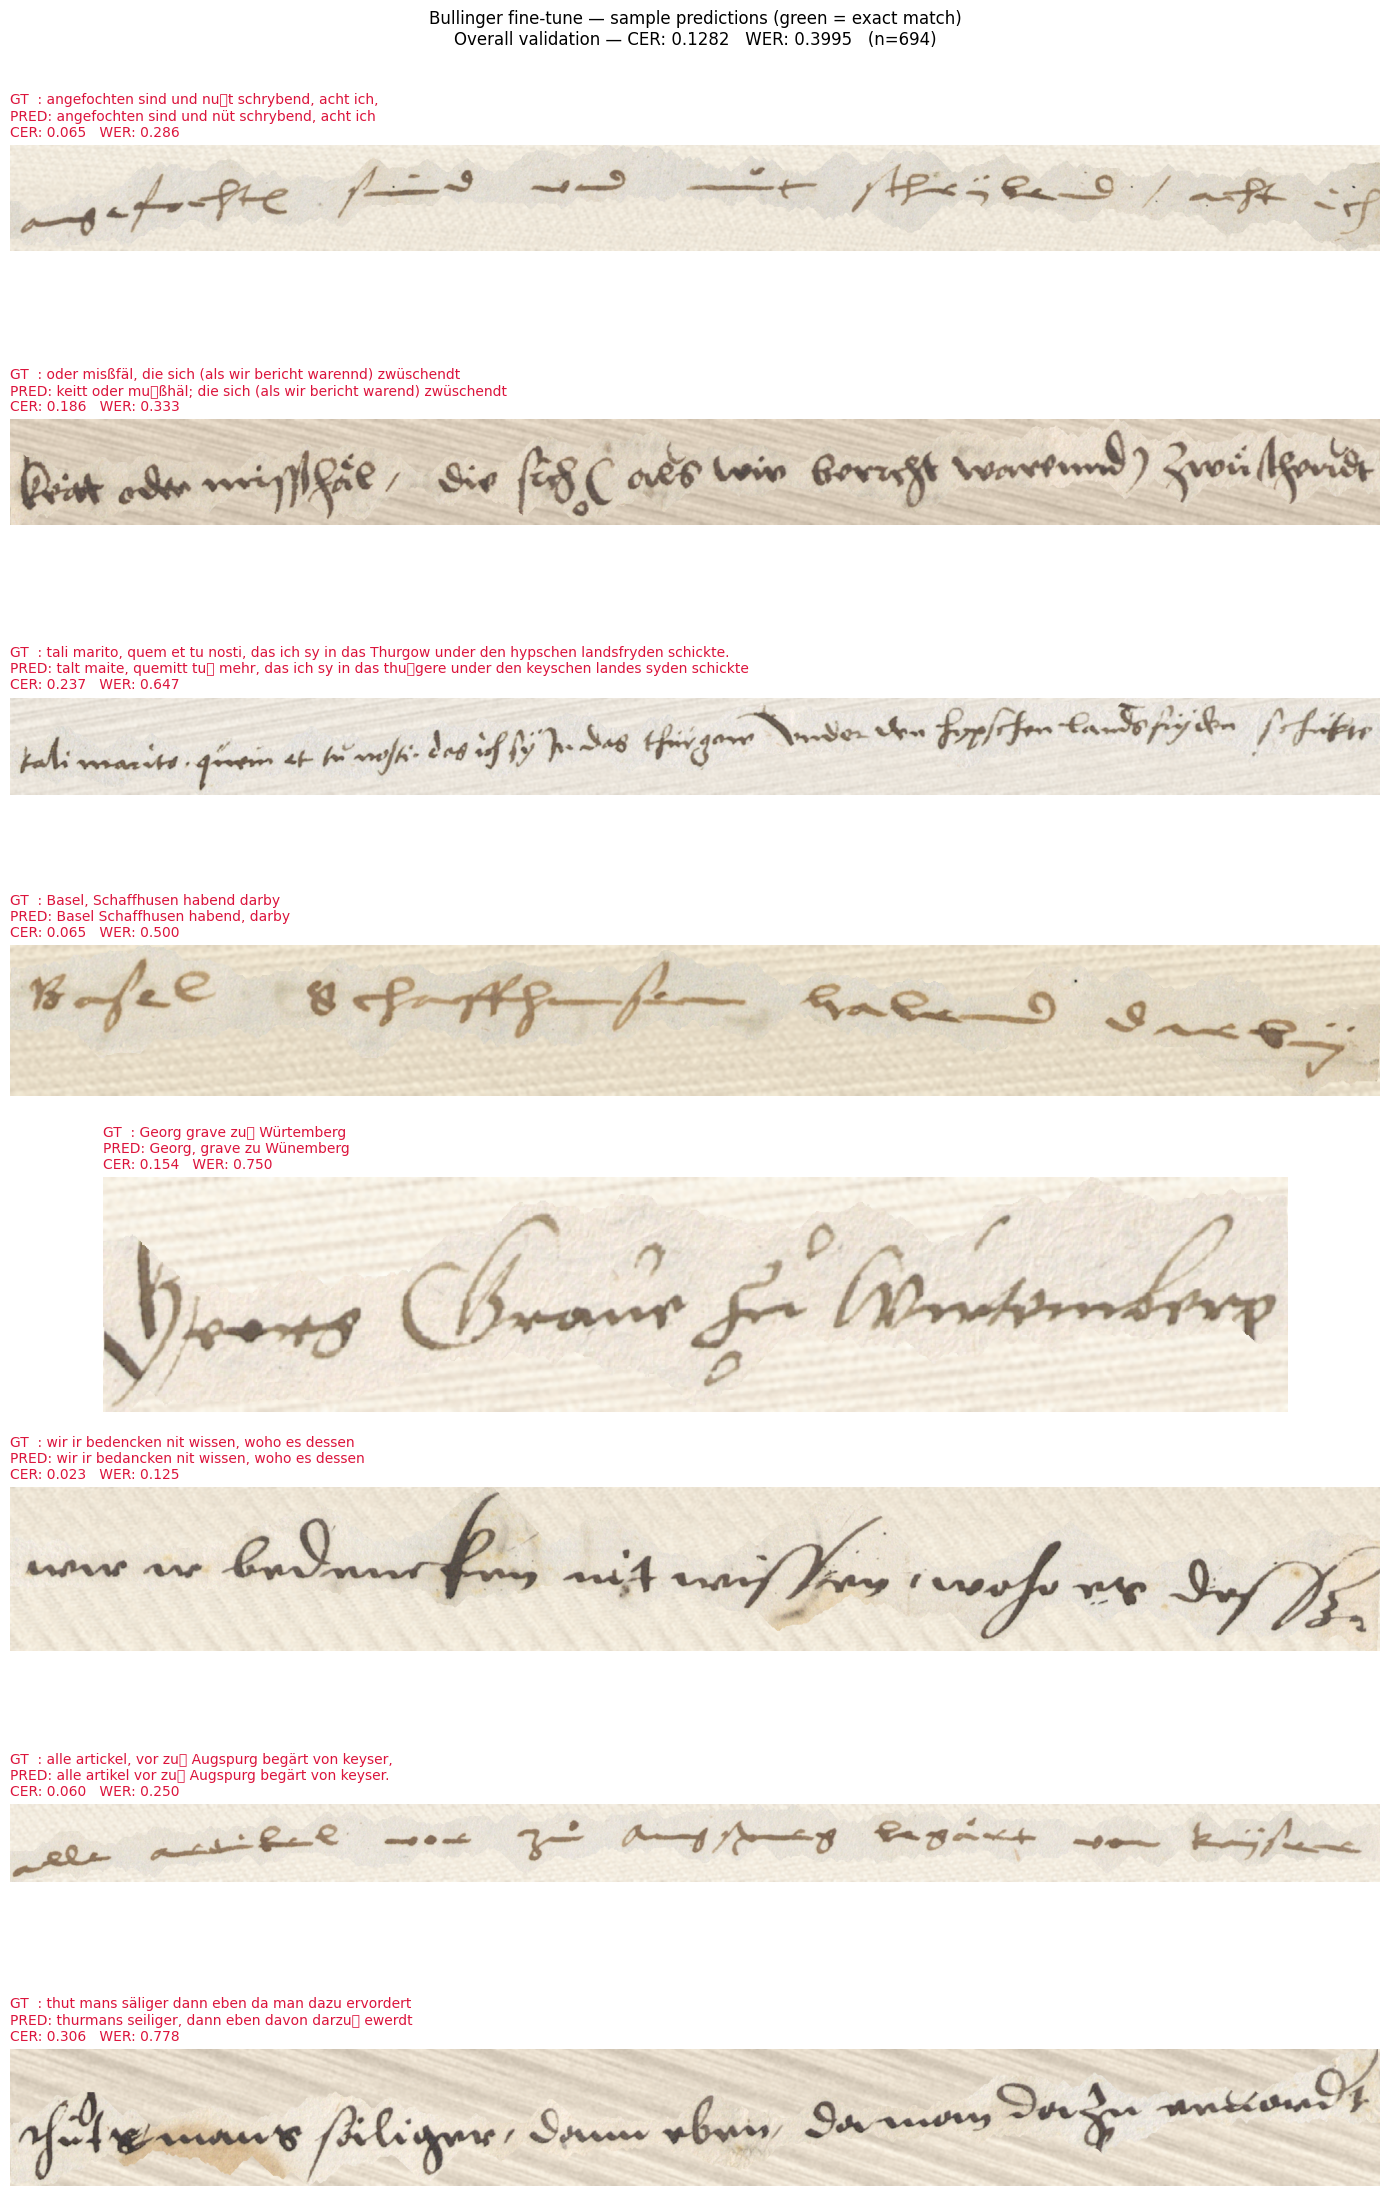

In [16]:
# Visualise sample predictions: line crop + ground-truth + prediction + per-line scores.
N_SHOW = 8
sample = val_df.sample(min(N_SHOW, len(val_df)), random_state=42).reset_index(drop=True)

model.eval()
fig, axes = plt.subplots(len(sample), 1, figsize=(14, 2.8 * len(sample)))
if len(sample) == 1:
    axes = [axes]

with torch.no_grad():
    for ax, row in zip(axes, sample.itertuples()):
        image = Image.open(row.file_name).convert("RGB")
        proc_image = eval_transforms(image)
        pixel_values = processor(proc_image, return_tensors="pt").pixel_values.to(device)
        generated_ids = model.generate(
            pixel_values, max_length=MAX_TARGET_LENGTH, num_beams=NUM_BEAMS,
        )
        pred = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

        line_cer = cer_metric.compute(predictions=[pred], references=[row.text])
        line_wer = wer_metric.compute(predictions=[pred], references=[row.text])
        match = pred.strip() == row.text.strip()

        ax.imshow(image, cmap="gray")
        ax.set_title(f"GT  : {row.text}\nPRED: {pred}\nCER: {line_cer:.3f}   WER: {line_wer:.3f}",
                     fontsize=10, loc="left",
                     color="green" if match else "crimson")
        ax.axis("off")

plt.suptitle(
    f"Bullinger fine-tune — sample predictions (green = exact match)\n"
    f"Overall validation — CER: {final_cer:.4f}   WER: {final_wer:.4f}   (n={len(all_refs)})",
    y=1.0,
)
plt.tight_layout()
plt.show()